<a href="https://colab.research.google.com/github/Sakshi-coder1/workco/blob/main/Excel_to_Python_Analytics_(D_4)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
df=pd.read_excel("superstore.xlsx")

In [38]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [39]:
df.shape

(51290, 21)

In [40]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  int64         
 15  qu

In [42]:
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [18]:
# Inpute numerical null values with mean
df['sales']=df['sales'].fillna(df['sales'].mean())

In [19]:
# Inpute categorical values with anything you want
df['product_name']=df['product_name'].fillna('unknown')

In [11]:
df.duplicated().sum()

np.int64(0)

In [20]:
#Remove duplicate records
df.drop_duplicates(inplace=True)

In [21]:
#Rename
df.rename(columns={'product_name':'product'},inplace=True)

In [22]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product', 'sales', 'quantity', 'discount',
       'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [23]:
# Changing data type
df['quantity']=df['quantity'].astype(int)

In [24]:
# Pivot tables using groupby()
df.groupby("region")["sales"].sum()


,sales
region,
Africa,783776
Canada,66932
Caribbean,324281
Central,2822399
Central Asia,752839
EMEA,806184
East,678834
North,1248192
North Asia,848349


In [25]:
# Profit by category
df.groupby("category")["profit"].sum().sort_values(ascending=False)


,profit
category,
Technology,663778.73318
Office Supplies,518473.83430
Furniture,286782.25380


In [26]:
# Top 10 products
df.groupby("product")["sales"].sum().sort_values(ascending=False).head(10)

,sales
product,
"Apple Smart Phone, Full Size",86936
"Cisco Smart Phone, Full Size",76441
"Motorola Smart Phone, Full Size",73159
"Nokia Smart Phone, Full Size",71904
Canon imageCLASS 2200 Advanced Copier,61600
"Hon Executive Leather Armchair, Adjustable",58200
"Office Star Executive Leather Armchair, Adjustable",50667
"Harbour Creations Executive Leather Armchair, Adjustable",50120
"Samsung Smart Phone, Cordless",48654


In [ ]:
# visulaization
# Sales by Region
df.groupby("region")["sales"].sum().plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show

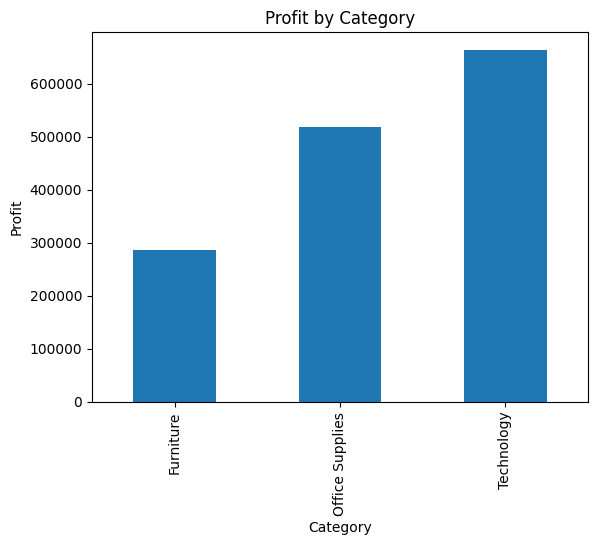

In [34]:
# Profit by category
df['profit'].groupby(df['category']).sum().plot(kind='bar')
plt.title("Profit by Category")
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

<Axes: ylabel='quantity'>

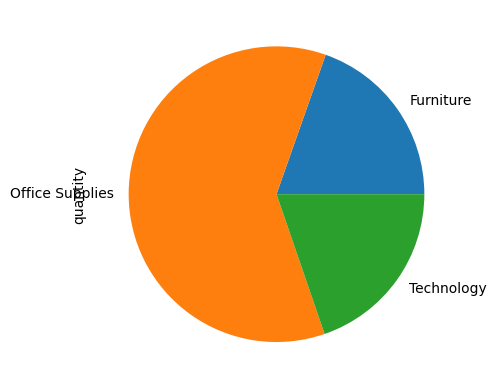

In [45]:
df.groupby("category")["quantity"].sum().plot(kind="pie")


In [46]:
df.groupby("category")["quantity"].sum()

,quantity
category,
Furniture,34954
Office Supplies,108182
Technology,35176
